### Load Dataset

First, load in the dataset and display the columns and first few columns

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

# load dataset, label as raw for clarity
raw = pd.read_csv("data/fed_rd_year&gdp.csv")
print(raw.columns)
print(raw.head)

Index(['department', '1976_gdp1790000000000.0', '1977_gdp2028000000000.0',
       '1978_gdp2278000000000.0', '1979_gdp2570000000000.0',
       '1980_gdp2797000000000.0', '1981_gdp3138000000000.0',
       '1982_gdp3314000000000.0', '1983_gdp3541000000000.0',
       '1984_gdp3953000000000.0', '1985_gdp4270000000000.0',
       '1986_gdp4536000000000.0', '1987_gdp4782000000000.0',
       '1988_gdp5155000000000.0', '1989_gdp5570000000000.0',
       '1990_gdp5915000000000.0', '1991_gdp6110000000000.0',
       '1992_gdp6435000000000.0', '1993_gdp6795000000000.0',
       '1994_gdp7198000000000.0', '1995_gdp7583000000000.0',
       '1996_gdp7978000000000.0', '1997_gdp8483000000000.0',
       '1998_gdp8955000000000.0', '1999_gdp9511000000000.0',
       '2000_gdp10148000000000.0', '2001_gdp10565000000000.0',
       '2002_gdp10877000000000.0', '2003_gdp11332000000000.0',
       '2004_gdp12089000000000.0', '2005_gdp12889000000000.0',
       '2006_gdp13685000000000.0', '2007_gdp14323000000000.0',
  

### Apply Tidy Data Principles

It appears there are two issues: the data is organized with years as columns, when they would be best as a single column (according to the principle of each observation in its own row.) Additionally, looking at the cols, it appears that something strange has happened with the names. From https://github.com/rfordatascience/tidytuesday/blob/main/data/2019/2019-02-12/fed_r_d_spending.csv, the numbers are national GDP, so we should split this into two cols.

It is also useful to reference the primary rules of tidy data, which are as follows: 
- Each variable is a column; each column is a variable.
- Each observation is a row; each row is an observation.
- Each value is a cell; each cell is a single value.

First, I melt the df so that there are 4 columns (corresponding to the first rule): department name, year, budget, and total GDP (previously part of the year variable name). Now, there is a unique observation in each row for every year and department.

In [3]:
# get the cols that contain budget values
cols = [c for c in raw.columns if '_gdp' in c]
melt = pd.melt(raw, id_vars=['department'], value_vars=cols, var_name='variable', value_name='budget')
print(melt.head)

# finalize changes to df
melt[['year','gdp']] = melt['variable'].str.split('_gdp',expand=True)
melt['gdp'] = melt['gdp'].astype(float)
melt['year'] = melt['year'].astype(int)
df = melt.drop('variable', axis=1)
print(df.head)

<bound method NDFrame.head of     department                  variable        budget
0          DHS   1976_gdp1790000000000.0           NaN
1          DOC   1976_gdp1790000000000.0  8.190000e+08
2          DOD   1976_gdp1790000000000.0  3.569600e+10
3          DOE   1976_gdp1790000000000.0  1.088200e+10
4          DOT   1976_gdp1790000000000.0  1.142000e+09
..         ...                       ...           ...
583        NIH  2017_gdp19177000000000.0  3.305200e+10
584        NSF  2017_gdp19177000000000.0  6.040000e+09
585      Other  2017_gdp19177000000000.0  1.553000e+09
586       USDA  2017_gdp19177000000000.0  2.625000e+09
587         VA  2017_gdp19177000000000.0  1.367000e+09

[588 rows x 3 columns]>
<bound method NDFrame.head of     department        budget  year           gdp
0          DHS           NaN  1976  1.790000e+12
1          DOC  8.190000e+08  1976  1.790000e+12
2          DOD  3.569600e+10  1976  1.790000e+12
3          DOE  1.088200e+10  1976  1.790000e+12
4         

### Visualization 1: Total Budget across Years

Now that the data is in a format with one observation for each department-year, we can proceed with further analysis. I use a pivot table to aggregate budgets by year to see how the total R&D budget has evolved

In [6]:
budget_year_sum = df.pivot_table(
    index='year',
    values='budget',
    aggfunc='sum'
)
print(budget_year_sum.head(5))

budget_year_mean = df.pivot_table(
    index='year',
    values='budget',
    aggfunc='mean'
)
print(budget_year_mean.head(5))

            budget
year              
1976  8.622700e+10
1977  9.180700e+10
1978  9.486400e+10
1979  9.660100e+10
1980  9.630500e+10
            budget
year              
1976  6.632846e+09
1977  7.062077e+09
1978  7.297231e+09
1979  7.430846e+09
1980  7.408077e+09


We can quickly plot this to see how the budget has changed over the years. One can see that the total R&D budget has increased significantly since 1980, with a dramatic period of growth directly preceding 2000. At that point, spending appears to have plateaued around $200 billion USD. Notably, the budget then fell dramatically around 2015, and seems to have been falling consistently since then. This may be a product of political turmoil in the United States that resulted in dramatic cuts to spending, although the simple panel dataset available to us does not allow us specific insights into the factors that may have contributed to the apparent trends.

<Figure size 1200x600 with 0 Axes>

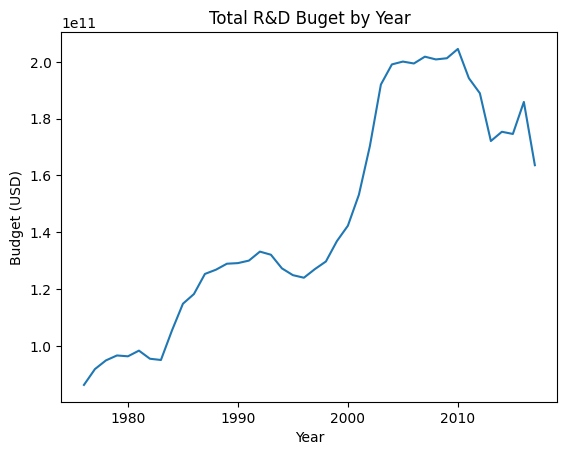

In [15]:
plt.figure(figsize=(12,6))
budget_year_sum.plot(y='budget', legend=False)
plt.title("Total R&D Buget by Year")
plt.xlabel("Year")
plt.ylabel("Budget (USD)")
plt.tight_layout
plt.show()

### Visualization 2: Total Budget by Department

We can also perform more complex visualizations using the (now) tidy data. The first shows the total R&D budgets for each of the departments contained in the data. The Department of Defense has by far the largest total budget over the dataset's timeframe at approximately 2.6 trillion USD. Health and Human Services and the National Institute of Health are the 2nd and 3rd R&D budgets, respectively, showing that medical/health research is still a priority in the government, though less so than defense and military development. Other well known scientific institutions follow, such as NASA, which has the 4th largest budget. This graph is able to show how the government's incentives are aligned, as military spending dwarfs almost all other departments by sheer budgetary size.

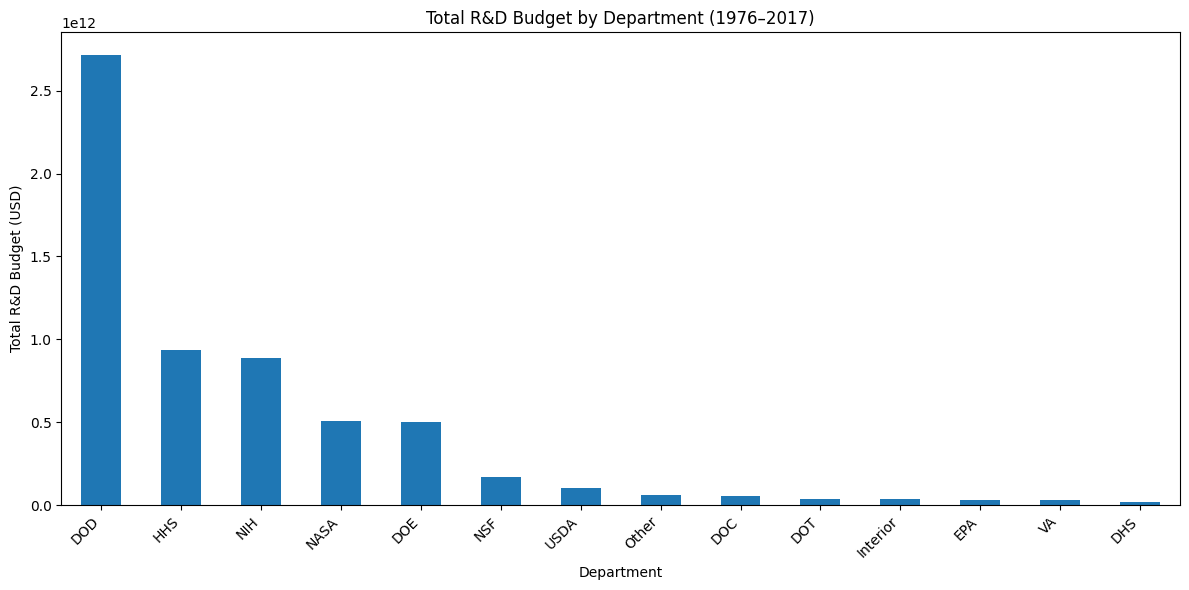

In [13]:
by_dept = df.groupby("department")["budget"].sum().sort_values(ascending=False)

plt.figure(figsize=(12,6))
by_dept.plot(kind="bar")
plt.title("Total R&D Budget by Department (1976–2017)")
plt.xlabel("Department")
plt.ylabel("Total R&D Budget (USD)")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

### Visualization 3: Budget Over Time for Top 5 Departments

This visualization shows how the budgets of the top 5 departments (as found above) have evolved over time. Relative to other departments, the R&D budget of the DOD appears far more prone to ebbs and flows, which may explain the patterns in visualization 1. Each of the other departments has relatively consistent spending, with some increasing slightly at the turn of the century but otherwise staying consistent and not facing any large increases or decreases. Indeed, it appears that the story told above about total R&D is almost entirely dictated by the budget of the military, rather than a more complex interplay between the different departments of the government.

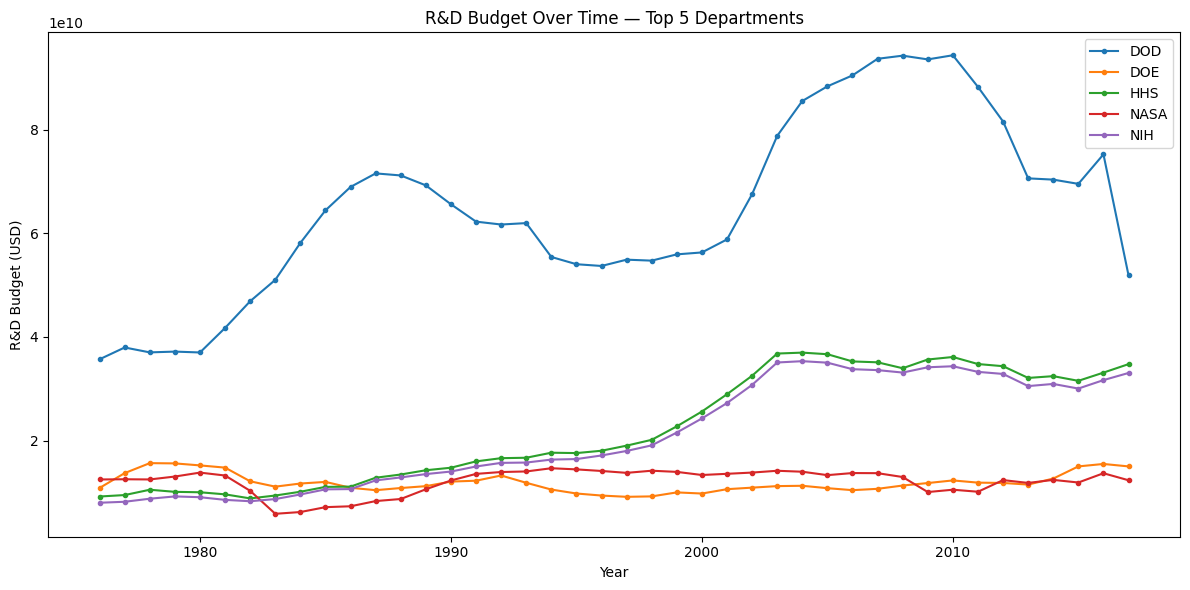

In [14]:
top5 = by_dept.head(5).index.tolist()
rd_top5 = df[df["department"].isin(top5)]

plt.figure(figsize=(12,6))
for dept, group in rd_top5.groupby("department"):
    plt.plot(group["year"], group["budget"], label=dept, marker="o", markersize=3)

plt.title("R&D Budget Over Time — Top 5 Departments")
plt.xlabel("Year")
plt.ylabel("R&D Budget (USD)")
plt.legend()
plt.tight_layout()
plt.show()

### Visualization 4: Budget Rankings Across Time

This additional visual uses an animated plot to track how the budget rankings (as seen in Visualization 2) change over time. Similar to the above graph, this gives the user an interactive means of looking at the comprehensive set of data across years. I chose this animated format as I felt a complete spaghetti plot for every department in the style of Visualization 3 may be too difficult to process all at once, and this adds a more interesting way to frame the data.

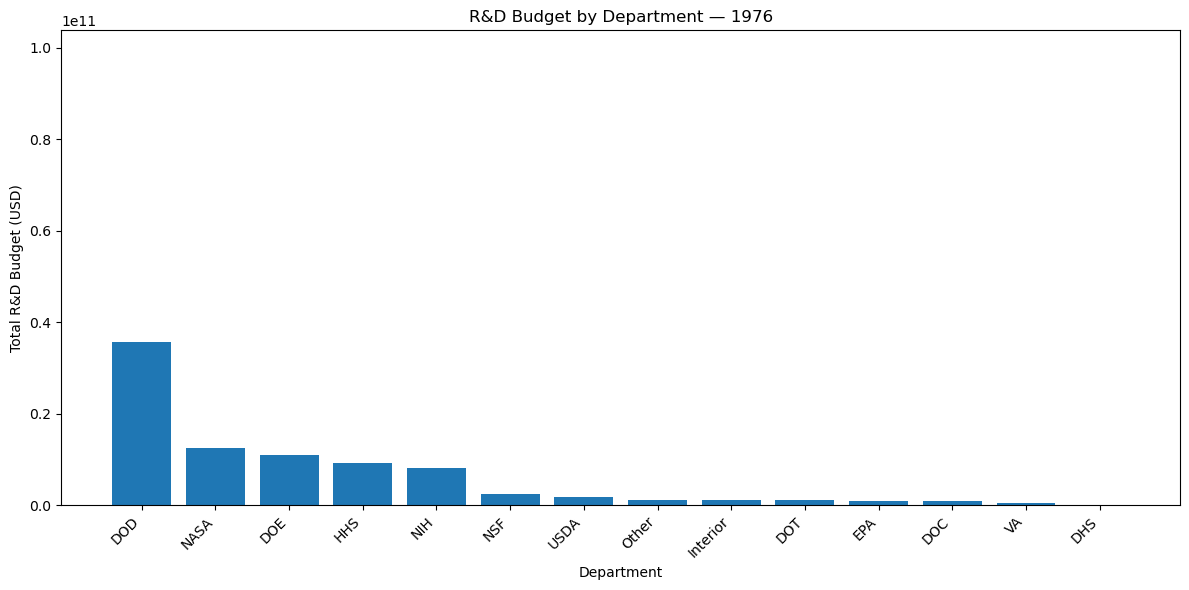

In [8]:
import matplotlib.pyplot as plt
import matplotlib.animation as animation
from IPython.display import HTML

yearly = (
    df.groupby(["year", "department"])["budget"]
    .sum()
    .reset_index()
)

years = sorted(yearly["year"].unique())
depts = yearly["department"].unique()

fig, ax = plt.subplots(figsize=(12, 6))

def update(year):
    ax.clear()

    frame = (
        yearly[yearly["year"] == year]
        .sort_values("budget", ascending=False)
    )

    ax.bar(frame["department"], frame["budget"])
    ax.set_title(f"R&D Budget by Department — {year}")
    ax.set_xlabel("Department")
    ax.set_ylabel("Total R&D Budget (USD)")
    plt.xticks(rotation=45, ha="right")
    ax.set_ylim(0, yearly["budget"].max() * 1.1) 
    plt.tight_layout()

ani = animation.FuncAnimation(
    fig,
    update,
    frames=years,
    interval=500,   
    repeat=False
)

HTML(ani.to_jshtml())